In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler

In [2]:
import pandas as pd
import numpy as np

In [3]:
from matplotlib import pyplot as plt

In [4]:
tensorflow.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
print(tensorflow.__version__)
print(tensorflow.config.list_physical_devices('GPU'))


2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
train_dir = r'dataset/images/train'
valid_dir = r'dataset/images/validation'

In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10,
)

In [8]:
train_ds = datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
)

valid_ds = datagen.flow_from_directory(
    valid_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [9]:
len(train_ds)

901

In [10]:
CLASS_NAMES = list(train_ds.class_indices.keys())  # Extract class names

In [11]:
CLASS_NAMES

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

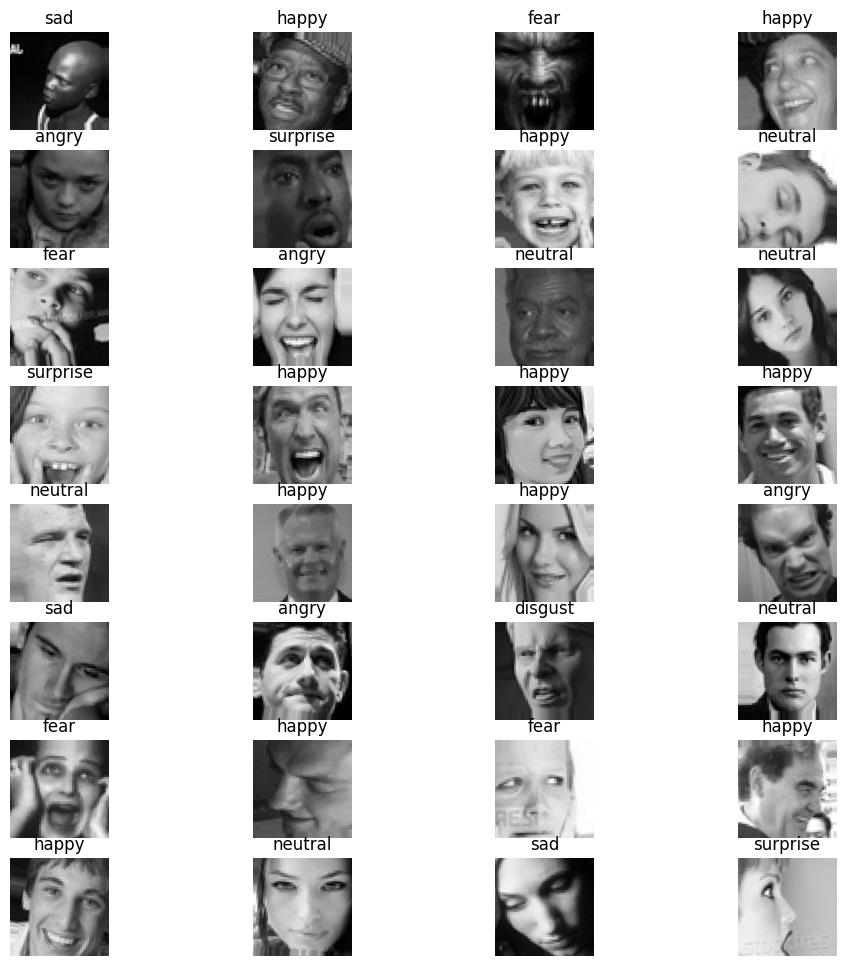

In [12]:
plt.figure(figsize=(12, 12))

images, labels = next(train_ds)
for index in range(32):
    plt.subplot(8, 4, index + 1)
    plt.imshow(images[index])
    plt.title(CLASS_NAMES[np.argmax(labels[index])])
    plt.axis('off')

plt.show()

In [13]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(200, 200, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(256, kernel_size=(2,2), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(7, activation='softmax'))

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 198, 198, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 99, 99, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                        

In [15]:
adam = Adam(learning_rate=0.0001)

In [16]:
def learning_rate(epochs, lr):
    if epochs < 15:
        return 0.001

    elif epochs < 30:
        return 0.0001

    else:
        return 0.00001

In [17]:
learning_rate_scheduler = LearningRateScheduler(learning_rate)

In [18]:
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(train_ds, epochs=50, validation_data=valid_ds, batch_size=64, callbacks=[learning_rate_scheduler])

Epoch 1/50
901/901 [==============================] - 221s 241ms/step - loss: 1.9437 - accuracy: 0.2301 - val_loss: 1.8141 - val_accuracy: 0.2583 - lr: 0.0010
Epoch 2/50
262/901 [=======>......................] - ETA: 2:05 - loss: 1.8258 - accuracy: 0.2524


KeyboardInterrupt



In [ ]:
Epoch 1/50
901/901 [==============================] - 916s 1s/step - loss: 1.9239 - accuracy: 0.2206 - val_loss: 1.8420 - val_accuracy: 0.2580
Epoch 2/50
901/901 [==============================] - 552s 613ms/step - loss: 1.8423 - accuracy: 0.2411 - val_loss: 1.7891 - val_accuracy: 0.2586
Epoch 3/50
901/901 [==============================] - 510s 565ms/step - loss: 1.8050 - accuracy: 0.2430 - val_loss: 1.7530 - val_accuracy: 0.2581
Epoch 4/50
901/901 [==============================] - 546s 605ms/step - loss: 1.7834 - accuracy: 0.2476 - val_loss: 1.9008 - val_accuracy: 0.2690
Epoch 5/50
901/901 [==============================] - 547s 607ms/step - loss: 1.7612 - accuracy: 0.2556 - val_loss: 1.7359 - val_accuracy: 0.2930
Epoch 6/50
901/901 [==============================] - 552s 612ms/step - loss: 1.7449 - accuracy: 0.2680 - val_loss: 1.7211 - val_accuracy: 0.2877
Epoch 7/50